In [1]:
# https://www.kaggle.com/code/rahulchauhan016/chest-x-ray-pneumonia-detection
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}, GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")

SEED = 42

BATCH_SIZE = 64
HEIGHT, WIDTH = 224, 224

TensorFlow version: 2.10.1, GPU: True


In [2]:
import os
from tensorflow.keras import layers

TRAIN_DIR = os.path.join(os.getcwd(), 'data', 'chest_xray', 'train')
VALIDATION_DIR = os.path.join(os.getcwd(), 'data', 'chest_xray', 'test')

loaded_training_dataset = tf.keras.utils.image_dataset_from_directory(TRAIN_DIR, shuffle=True, seed=SEED,
                                                                      image_size=(HEIGHT, WIDTH),
                                                                      batch_size=BATCH_SIZE, label_mode='int')

loaded_validation_dataset = tf.keras.utils.image_dataset_from_directory(VALIDATION_DIR, shuffle=False, seed=SEED,
                                                                        image_size=(HEIGHT, WIDTH),
                                                                        # color_mode='grayscale',
                                                                        batch_size=BATCH_SIZE, label_mode='int')

data_augmentation = tf.keras.Sequential([layers.Rescaling(1. / 255),
                                         layers.RandomFlip("horizontal"),
                                         layers.RandomRotation(0.05),
                                         layers.RandomZoom(0.1)])
rescale_only = tf.keras.Sequential([layers.Rescaling(1. / 255)])

class_names = loaded_validation_dataset.class_names

AUTOTUNE = tf.data.AUTOTUNE

training_ds = loaded_training_dataset.shuffle(1000)
training_ds = training_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
training_ds = training_ds.prefetch(AUTOTUNE)

validation_ds = loaded_validation_dataset.map(lambda x, y: (rescale_only(x), y), num_parallel_calls=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(AUTOTUNE)

print("class names in dataset are ", class_names)
for i, (images, labels) in enumerate(training_ds.take(1)):
    print(f"training_ds Batch {i + 1}  image shape {images.shape} and labels shape {labels.shape}")

# to check samples count in training set and validation set
import numpy as np

train_labels_check = np.concatenate([y.numpy() for _, y in training_ds])
val_labels_check = np.concatenate([y.numpy() for _, y in validation_ds])

print("Train distribution:", np.bincount(train_labels_check))
print("Val distribution:", np.bincount(val_labels_check))

Found 5232 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
class names in dataset are  ['NORMAL', 'PNEUMONIA']
training_ds Batch 1  image shape (64, 224, 224, 3) and labels shape (64,)
Train distribution: [1349 3883]
Val distribution: [234 390]


# ResNet50 with class weights
## input 224x224x3

In [3]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_curve, auc

labels = np.concatenate([y.numpy() for _, y in training_ds])
print(labels)

class_weights_array = compute_class_weight(class_weight='balanced',
                                           classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(class_weights_array))
print("Class Weights:", class_weights)

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(HEIGHT, WIDTH, 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.25)(x)
output = Dense(1, activation='sigmoid')(x)

transfer_ResNet50_model = Model(inputs=base_model.input, outputs=output)

transfer_ResNet50_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

transfer_ResNet50_model.summary()

history_transfer_ResNet50 = transfer_ResNet50_model.fit(training_ds, validation_data=validation_ds, epochs=10,
                                                        class_weight=class_weights)

[1 1 1 ... 1 1 0]
Class Weights: {0: 1.939214232765011, 1: 0.6737058975019315}
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
               

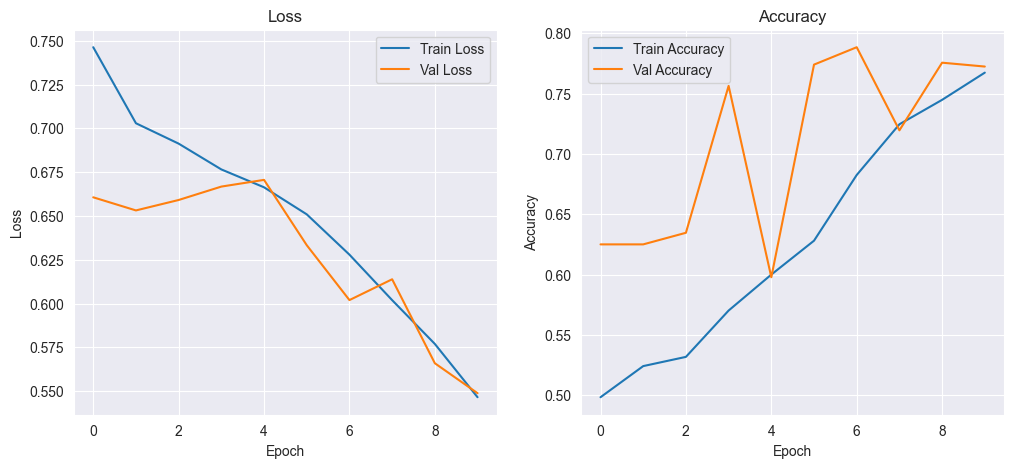

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
# Loss
plt.subplot(1, 2, 1)
plt.plot(history_transfer_ResNet50.history['loss'], label='Train Loss')
plt.plot(history_transfer_ResNet50.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_transfer_ResNet50.history['accuracy'], label='Train Accuracy')
plt.plot(history_transfer_ResNet50.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### Evaluating Metric

              precision    recall  f1-score   support

      NORMAL       0.74      0.53      0.62       234
   PNEUMONIA       0.76      0.89      0.82       390

    accuracy                           0.76       624
   macro avg       0.75      0.71      0.72       624
weighted avg       0.75      0.76      0.75       624

ROC value is :  0.8375082182774491


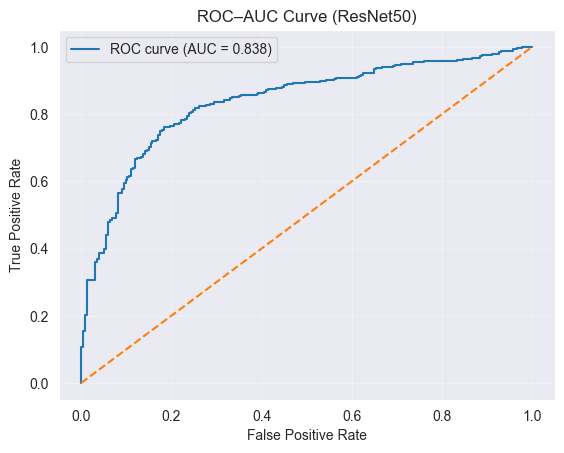

Confusion Matrix:
 [[125 109]
 [ 43 347]]


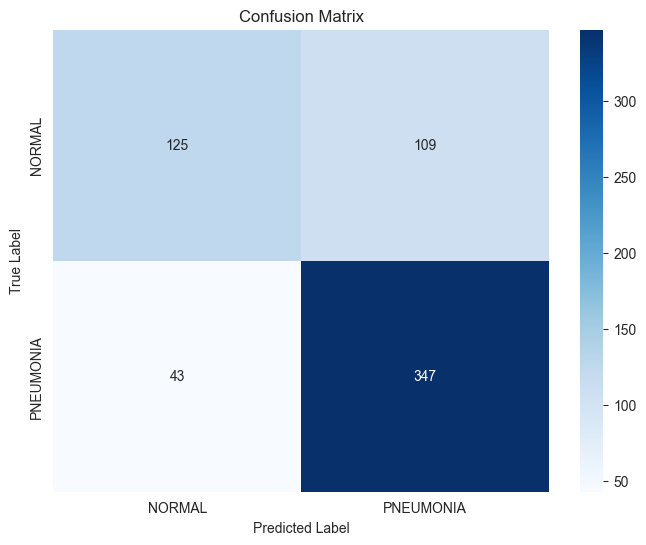

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []
y_scores = []
classes = ["NORMAL", "PNEUMONIA"]

for images, labels in validation_ds:
    probs = transfer_ResNet50_model.predict(images, verbose=0)

    y_scores.extend(probs.ravel())
    y_pred.extend((probs > 0.35).astype(int).ravel())
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=classes))

# ROC (Receiver Operating Characteristic) –AUC (probability-based)
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
print("ROC value is : ", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC–AUC Curve (ResNet50)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# confusion matrix
y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.savefig("plot_loss_accuracy.png")
plt.show()

plt.close()

## Grad-CAM visualization

C:\Users\zabeeh\PycharmProjects\DeepLearning\CompleteProjects\PneumoniaDetection\data\chest_xray\train\NORMAL\IM-0160-0001.jpeg


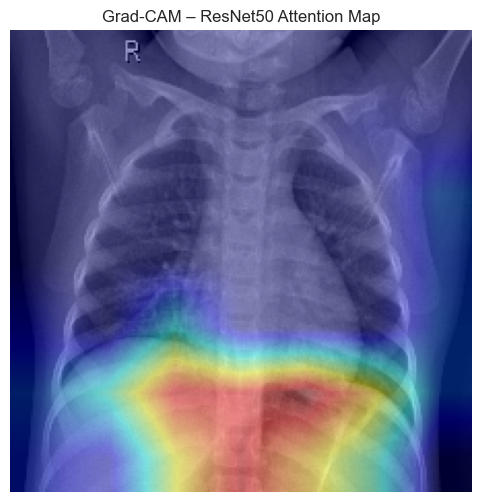

In [18]:
LAST_CONV_LAYER = "conv5_block3_out"

import cv2
import glob


def make_gradcam_heatmap(img_array, model, last_conv_layer_name=LAST_CONV_LAYER):
    grad_model = tf.keras.models.Model([model.inputs],
                                       [model.get_layer(last_conv_layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()


img_path = glob.glob(os.path.join(TRAIN_DIR, '**', '*.jpeg'), recursive=True)[23]
print(img_path)

# img_path = os.path.join(TRAIN_DIR, test_generator.filenames[idx])
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(HEIGHT, WIDTH))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

heatmap = make_gradcam_heatmap(img_array, transfer_ResNet50_model)

orig_img = cv2.imread(img_path)
orig_img = cv2.resize(orig_img, (HEIGHT, WIDTH))
heatmap_resized = cv2.resize(heatmap, (HEIGHT, WIDTH))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(orig_img, 0.6, heatmap_color, 0.4, 0)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM – ResNet50 Attention Map")
plt.axis('off')
plt.show()

from sklearn.metrics import classification_report, confusion_matrix


# DenseNet
## input 224x224x3

In [ ]:
from tensorflow.keras.applications import DenseNet121, DenseNet169, DenseNet201
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))       # Option 1: DenseNet121 (smallest, fastest)
# base_model = DenseNet169(weights='imagenet', include_top=False, input_shape=(224, 224, 3))    # Option 2: DenseNet169 (middle ground)
# base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224, 224, 3))     # Option 3: DenseNet201 (largest, most accurate)

# Freeze base model layers
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# model.summary()

callbacks_dense = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    # ModelCheckpoint('best_densenet_pneumonia.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history_denseNet = model.fit(training_ds, validation_data=validation_ds, epochs=10,
                             callbacks=callbacks_dense, verbose=1)




In [ ]:
from sklearn.metrics import  classification_report

y_true = []
y_pred = []
y_scores = []
classes = ["NORMAL", "PNEUMONIA"]

for images, labels in validation_ds:
    probs = transfer_ResNet50_model.predict(images, verbose=0)

    y_scores.extend(probs.ravel())
    y_pred.extend((probs > 0.35).astype(int).ravel())
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=classes))

# ROC (Receiver Operating Characteristic) –AUC (probability-based)
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
print("ROC value is : ", roc_auc)

# Effient Net

In [ ]:
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB4, EfficientNetB7
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.models import Sequential

# EfficientNetB0 (smallest, fastest)
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)  # B0: 224, B4: 380, B7: 600
)

# Key advantages:
# 1. State-of-the-art accuracy
# 2. Parameter efficient
# 3. Scalable architecture
# 4. Good for medical imaging

img_size = (224, 224)
channels = 3
img_shape = (224, 224, 3)

# create pre-trained model (you can built on pretrained model such as :  efficientnet, VGG , Resnet )
# we will use efficientnetb3 from EfficientNet family.
base_model = tf.keras.applications.efficientnet.EfficientNetB0(include_top=False, weights="imagenet",
                                                               input_shape=img_shape, pooling='max')
# base_model.trainable = False

model = Sequential([
    base_model,
    BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
    Dense(256, kernel_regularizer=regularizers.l2(l=0.016), activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006), activation='relu'),
    Dropout(rate=0.45, seed=123),
    Dense(2, activation='softmax')
])

model.compile(Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

In [ ]:
from sklearn.metrics import  classification_report

y_true = []
y_pred = []
y_scores = []
classes = ["NORMAL", "PNEUMONIA"]

for images, labels in validation_ds:
    probs = transfer_ResNet50_model.predict(images, verbose=0)

    y_scores.extend(probs.ravel())
    y_pred.extend((probs > 0.35).astype(int).ravel())
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=classes))

# ROC (Receiver Operating Characteristic) –AUC (probability-based)
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
print("ROC value is : ", roc_auc)